# Notebook for general analysis of Petz recovery on one-to-all systems

This notebook serves as an introduction to one-to-all systems and using Petz recovery. Being a precursor to the main notebook, we consider a more straight-forward example instead of the more complicated quantum darwinism application. Here, Petz recovery is applied in the more traditional sense, meaning we apply recovery on the system after the initial encoding channel / decoherence as occurred. As in other materials provided, a brief introduction to associated theory is given but readers are encouraged to look for additional sources to learn the basics of the topic.

### Introduction

As in the paper, the general idea is to consider a multipartite system consisting of a single-qubit principal part $\Gamma$, and an environment / apparatus $\Xi=\cup_{i=1}^N\Xi_i$ made up of $N$ qubits. The system is coupled to each qubit in the apparatus via the Hamiltonian

$$
H=O_\Gamma\otimes O_\Xi=Z_\Gamma\otimes\sum_{l=1}^N g_l~ \mathbb{I}_2^{\otimes(l-1)}\otimes Z_{\Xi_l}\otimes\mathbb{I}_2^{\otimes(N-l)}~,
$$
where where $Z$ is the Pauli Z operator, and $\Xi_l$ refers to the $l$:th subsystem of the apparatus. The environment is taken to start in a ready-to-read state which is just a general tensor product state of pure states $\ket{\Xi_R}=\bigotimes_{l=1}^N(\alpha_l\ket{0}_l+\beta_l\ket{1}_l)$, where the states are not eigenstates of $O_\Xi$. After turning on this interaction and letting it take place for a given time $t$, the system experiences a decoherence channel, such that for any given qubit density matrix

$$
\rho_\Gamma = \begin{pmatrix}  \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11}  \end{pmatrix}~,
$$

the decoherence $\Lambda_t:\mathcal{D}(\Gamma)~\rightarrow~\mathcal{D}(\Gamma)$ has the action of

$$
\begin{pmatrix}  \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11}  \end{pmatrix}~\rightarrow~
\begin{pmatrix}  \rho_{00} & \rho_{01}\gamma(t) \\ \rho_{10}\gamma^*(t) & \rho_{11}  \end{pmatrix}~,
$$
where we define
$$
\gamma(t)=\prod_{l=1}^N\left(||\alpha_l||^2e^{-2ig_l t}+||\beta_l||^2e^{2ig_l t}\right)~.
$$
The associated Petz map $\mathcal{P}^s_{\Lambda_t}$ is then defined just as before, i.e. for a system starting from $\rho_i$, we can try recovering the decohered state $\rho_f=\Lambda(\rho_i)$ via

$$
\mathcal{P}_{\Lambda}^{s}(\rho_f)\equiv \sqrt{s}\Lambda^{\dagger}[\Lambda(s)^{-\frac{1}{2}}\rho_f\Lambda(s)^{-\frac{1}{2}}]\sqrt{s}~.
$$

To summarize, the key difference is that we only consider what happends to the system, which serves as an introduction to the topics and tools used in the main notebook and paper. To simplify even further, we take the system and environment observables to all be the Pauli Z instead of other possibilities. Moreover, visualization of these processes is quite a bit more simple so one can use this framework for analyzing the behaviour of the Petz and dynamics generated by the Hamiltonian.

### Importing libraries and setting up

We begin by importing local modules and key libraries like QuTiP and NumPy. If the use of these is not too familiar, do not worry. Most functions are quite intuitive to understand and we try to provide some explanation for each non-trivial feature used. However, reading provided documentation is encouraged for obvious reasons!

Additionally, we do a very general setup phase to declare variables and such. Here, one can for example set the size of the system and control what kind of couplings are used. 

In [2]:
# library imports
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

# local file imports
import sys
import os
sys.path.append(os.path.abspath(".."))

import src.utility_functions as utils
import src.recovery_utilities as rec

Some additional notes here are that we use the Bloch vector convention to form any desirable qubit state, i.e.

$$
\rho_\Gamma(t=0)=\frac{1}{2}(\mathbb I+\vec{a}\cdot\vec{\sigma})~~,~\vec{a}=(r\sin\theta\cos\phi,r\sin\theta\sin\phi,r\cos\theta)~,
$$
and $\vec{\sigma}=(X,Y,Z)$. Additionally, some later sections take use of the Liouville superoperator formalism for density operators. Essentially, a vectorised density operator is just a reshaping of the matrix into a column vector, such that the map can be applied as one big matrix. As an example, let us look at the decoherence map presented above. Using the same notation for the initial density operator $\rho_i$, the action of decoherence can be depicted with a superoperator $S_{\Lambda_{t}}$ and a vectorised density operator $\text{vec}(\rho_i)$ such that

$$
    S_{\Lambda_{t}}\cdot\text{vec}(\rho_i) =
    \begin{pmatrix}
    1 & 0 & 0 & 0 \\
    0 & \gamma(t) & 0 & 0 \\
    0 & 0 & \gamma^*(t) & 0 \\
    0 & 0 & 0 & 1\end{pmatrix}\cdot
    \begin{pmatrix}
    \rho_{00} \\
    \rho_{01} \\
    \rho_{10} \\
    \rho_{11}\end{pmatrix} = \begin{pmatrix}
    \rho_{00} \\
    \rho_{01}\gamma(t) \\
    \rho_{10}\gamma^*(t) \\
    \rho_{11}\end{pmatrix}
    
    = \text{vec}(\rho_f)~.
$$

In essence, nothing but notation changes for the most part. The point of using this formalism is that the decoherence map is exceptionally easy to write in this way. Moreover, QuTiP provides tools to switch from one formalism to another with a simple function so this does not end up causing us problems, on the contrary even!

In [3]:
"""
Define necessary variables for initializing said states/systems.
"""

N = 7                   # Number of qubits in apparatus
array_dist = "uniform"  # What type of distribution you want to pull numbers out of // "uniform", "normal", "gamma"
g_low = 0.1            # Coupling constant array lower bound
g_hgh = 1.0            # Coupling constant array higher bound
g_seed = 1000           # Seed for coupling array


# random number generator
rng = np.random.default_rng(seed=55555)

# create the initial state of the environment and save the \alpha_k, beta_k coefficients
xi = [rand_dm(2, seed=rng) for _ in range(N)]
xi_coeff = [[state.full()[0][0], state.full()[1][1]] for state in xi]


# Initialize N qubits of the apparatus in the plus state
init_xi_kets = [(basis(2,0) + basis(2,1)).unit() for i in range(N)]

# Define length, polar angle and azithmutal angle for bloch vector
r = 1
theta = np.pi / 2
phi = 0

# Create initial state of the system as per the definition in the above cell
init_gamma = utils.generate_state_from_coords([r, theta, phi])

# Generate array of coupling constants g_l between system and apparatus
coupling_array = utils.generate_real_array(n=N, type=array_dist, seed=g_seed, low_lim=g_low, hgh_lim = g_hgh, order=None)

# Generate an array of time steps to consider for the decoherence and recovery
times = np.linspace(0, 15, 500)


### Performing Petz recovery

Now that the stage is set, we are ready to try recovering with the Petz map. As we are considering the decoherence channel for many different times, we will naturally have as many Petz maps to form. To simplify these calculations in the hopes of reducing computation time, we set the reference state $s\in\mathcal{D}(\Gamma)$ to be some fixed state across all recoveries.

Additionally, we need some measure for how successful recovery was. To this end, we utilize root fidelity, defined between two density matrices, the initial state $\rho_i$ and the recovered state $\rho_r$, as 

$$
    F(\rho_i,\rho_r)=\text{Tr}\sqrt{\sqrt{\rho_i}\rho_r\sqrt{\rho_i}}~.
$$
A valid question is to ask whether using the Petz is even a good idea. To cast some light on this topic, we also compute the fidelity between the initial state and the decohered states to show that the Petz performs better than simply doing nothing / applying the identity.

In [4]:
"""
Loop through all times to consider and calculate the success of recovery
for each value. Save the state of the system at each time step to showcase
how the system evolves on the Bloch sphere later.
"""
fidelities = []
deco_fidelities = []

# list for qobjs at different times
evolved_states = []
recovered_states = []

# Define a reference to be used, default here is the maximally mixed state.
ref = 1/2 * qeye(2)
for t in times:

    # calulate appropriate decoherence for off-diagonal terms
    gamma_func = utils.decoherence_gamma(N=N, coeff = xi_coeff, g_k = coupling_array, t = t)

    # Create a numpy array, which corresponds to the superoperator of the CPTP map
    data_for_op = np.array([

        [1, 0, 0, 0],
        [0, gamma_func, 0, 0],
        [0, 0, np.conjugate(gamma_func), 0],
        [0, 0, 0, 1]

            ])
    
    # Create said superoperator as a quantum object with correct dimensions
    S = Qobj(arg = data_for_op, dims=[[[2], [2]], [[2], [2]]])


    """
    Evolve initial state to current time t with the superoperator
    and save the state for later use. Note that we go back and forth a lot between vectorized operators
    and density operators here...

    """

    evolved = S * operator_to_vector(init_gamma)
    evolved_dm = vector_to_operator(evolved)
    evolved_states.append(evolved_dm)

    # Calculate and save fidelity between initial state and decohered state at time t
    deco_fidelities.append(fidelity(init_gamma, evolved_dm))

    """
    Petz map as a superoperator. This naturally depends on
    the reference and decoherence map. The process can be quite complicated and further details
    are encouraged to be read from documentation, but in short, we create the total superoperator
    from pre- and postprodcuts of multiple operators which the Petz is constructed from.

    """

    # Petz in superoperator form
    P = rec.petz_map_states(S, ref)

    # Apply the Petz to decohered state, make a density matrix version
    recovered = P * evolved
    recovered_dm = vector_to_operator(recovered)
    recovered_states.append(recovered_dm)

    # Calculate fidelity between initial state and the recovered state using
    # QuTips built-in function that uses the definition from Nielsen & Chuang

    fidelities.append(fidelity(init_gamma, recovered_dm))


### Visualization

As promised, now is the time to visualize all of the above. In the end, we will have two different plots: One which showcases the recovery fidelity of the Petz and a Bloch sphere with two "trajectories", showcasing how decoherence evolves the initial state and what the Petz map does to the decohered states.

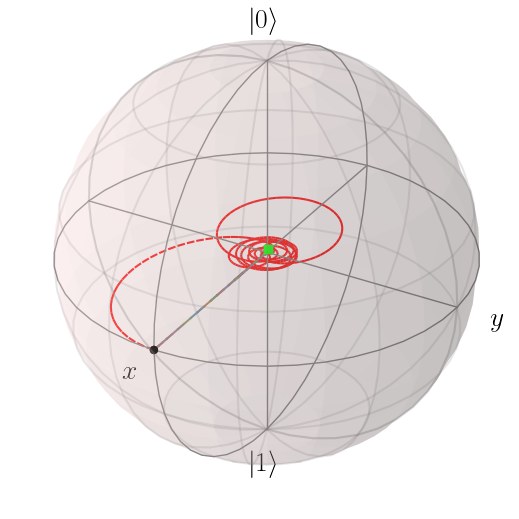

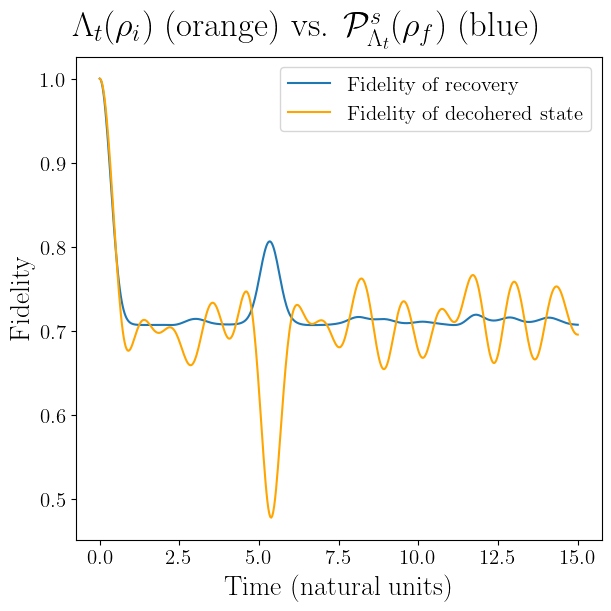

In [ ]:
# Matplotlib settings
plt.rc('text', usetex = True)
plt.rc('font', family = 'Times New Roman')

"""
Here is the Bloch sphere plot. In short, we create points that correspond to decohered states produced in the last sections
and then draw lines between them to illustrate the evolution of the principal system under this interaction.

The commented lines in the for loop are to showcase where the Petz maps the decohered states
"""

# initalize sphere object
bs = Bloch()

# add points that correspond to the initial state and final state
bs.add_states([init_gamma], kind="point", colors="black")
bs.add_states([evolved_states[-1]], kind="point", colors="lime")


# loop through states to create lines between them
for i in range(1, len(evolved_states)):

    A = evolved_states[i -1]
    B = evolved_states[i]
    bs.add_line(A, B, fmt="--r")

    # C = recovered_states[i - 1]
    # D = recovered_states[i]
    # bs.add_line(C, D, fmt="-")

# show sphere
bs.show()



# Fidelity plotting
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

# Plot fidelity as a function of time
#ax.plot(times, [0.7]*len(times), alpha=0.5, dashes=[3, 3], color="white", label="Minimum limit of recovery fidelity")
ax.plot(times, fidelities, label="Fidelity of recovery")
ax.plot(times, deco_fidelities, label="Fidelity of decohered state", color="orange")

# Set labels and title etc.
ax.set_xlabel("Time (natural units)", fontsize = 20)
ax.set_ylabel("Fidelity", fontsize = 20)
fig.suptitle(r"$\Lambda_t(\rho_i)$ (orange) vs. $\mathcal{P}_{\Lambda_t}^s(\rho_f)$ (blue)", fontsize = 25)

#fix fluctuating by setting limits to y axis
#ax.set_ylim(-0.1, 1.1)
#ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.tick_params(labelsize = 15)

plt.legend(fontsize = 15)

# Show graphs
plt.show()